# MedCore Catalogue — Table Extraction Benchmark
**Track B: Table Extraction** — benchmarking grid-reconstruction baselines built on **EasyOCR** and **Tesseract** against the programmatically-verified table ground truth (`gt_table_html` / `gt_table_markdown` / `gt_table_cells`) generated for the MedCore synthetic catalogue.

**Inputs expected (add as Kaggle Dataset / Notebook Input):**
- `MedCore_Catalogue_v2.pdf` — the source document (zip-based container of per-page JPEGs + text)
- `MedCore_GT_v2_with_tables.json` — layout GT augmented with verified table structure (HTML/Markdown/cell-JSON) for the 2 `table`-class elements (**primary GT source**)
- `MedCore_table_gt.json` — lightweight standalone tables-only GT (fallback source)

**Models benchmarked:** Neither EasyOCR nor Tesseract is a table-structure model — they only detect words/boxes. So this notebook builds a **simple, documented grid-reconstruction baseline** on top of each: cluster detected word boxes into rows (by y-center gaps) and columns (by x-center gaps), then assign words to grid cells. This is intentionally a weak baseline — the point of Track B is to see how far raw OCR gets vs. a real table-structure model (Table-Transformer / Docling / TATR), which is a natural next baseline to add to this same harness later.

**Metrics:** **TEDS** and **TEDS-Struct** (Tree-Edit-Distance Similarity, PubTabNet-style, implemented here with `apted` and verified against known-answer test cases), plus a simple cell-level exact-match grid accuracy as a cheap sanity metric — per the Track B metrics decided in the benchmarking research report.

> ⚠️ **Before running:** in Kaggle notebook Settings, turn **Internet → On** (needed to `pip install easyocr jiwer apted lxml pytesseract` and `apt-get install tesseract-ocr`).


## 1. Setup

In [1]:
!pip install --quiet jiwer easyocr pytesseract apted lxml
!apt-get update -qq && apt-get install -y -qq tesseract-ocr || true



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


'apt-get' is not recognized as an internal or external command,
operable program or batch file.
'true' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os, glob, json, re, io, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 60)


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Locate Input Files

In [3]:
SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working", "."]

def find_file(patterns, search_roots=SEARCH_ROOTS):
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for pattern in patterns:
            matches = sorted(glob.glob(os.path.join(root, "**", pattern), recursive=True))
            if matches:
                return matches[0]
    return None

MANUAL_PATHS = {"pdf": None, "gt_with_tables": None, "gt_tables_only": None}

PATHS = {
    "pdf":             MANUAL_PATHS["pdf"]            or find_file(["*MedCore_Catalogue*.pdf", "*.pdf"]),
    "gt_with_tables":  MANUAL_PATHS["gt_with_tables"] or find_file(["*MedCore_GT_v2_with_tables*.json"]),
    "gt_tables_only":  MANUAL_PATHS["gt_tables_only"] or find_file(["*MedCore_table_gt*.json"]),
}

print("Resolved input paths:")
for k, v in PATHS.items():
    print(f"  {k:18s} -> {v}")

assert PATHS["pdf"] is not None, "Could not find the catalogue PDF — set MANUAL_PATHS[\'pdf\']"
assert (PATHS["gt_with_tables"] or PATHS["gt_tables_only"]) is not None, \
    "Could not find a table GT file — set a MANUAL_PATHS entry"


Resolved input paths:
  pdf                -> .\MedCore_Catalogue_v2.pdf
  gt_with_tables     -> .\MedCore_GT_v2_with_tables.json
  gt_tables_only     -> .\MedCore_table_gt.json


## 3. Load Page Images

In [4]:
def load_page_images(path):
    """The catalogue \'PDF\' is actually a zip container of per-page JPEGs +
    text + manifest.json (confirmed during GT generation). Falls back to
    PyMuPDF rendering if given a real PDF."""
    images = {}
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as z:
            names = z.namelist()
            manifest_name = next((n for n in names if n.endswith("manifest.json")), None)
            if manifest_name:
                manifest = json.loads(z.read(manifest_name))
                for p in manifest["pages"]:
                    img_bytes = z.read(p["image"]["path"])
                    images[p["page_number"]] = Image.open(io.BytesIO(img_bytes)).convert("RGB")
            else:
                for n in names:
                    if n.lower().endswith((".jpg", ".jpeg", ".png")):
                        stem = os.path.splitext(os.path.basename(n))[0]
                        if stem.isdigit():
                            images[int(stem)] = Image.open(io.BytesIO(z.read(n))).convert("RGB")
    else:
        try:
            import fitz
        except ImportError:
            os.system("pip install --quiet pymupdf")
            import fitz
        doc = fitz.open(path)
        for i, page in enumerate(doc, start=1):
            pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
            images[i] = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    return images

page_images = load_page_images(PATHS["pdf"])
print(f"Loaded {len(page_images)} page images.")


Loaded 4 page images.


## 4. Load Table Ground Truth & Crop Table Regions

In [5]:
def load_table_gt():
    """Returns a dict {table_id: {page, bbox_norm, html, markdown, cells, meta}}."""
    tables = {}
    if PATHS["gt_with_tables"]:
        gt_full = json.load(open(PATHS["gt_with_tables"], encoding="utf-8"))
        for page in gt_full["pages"]:
            for el in page["elements"]:
                if el.get("gt_table_status") == "programmatic_verified":
                    tables[el["id"]] = {
                        "page": el["page"], "bbox_norm": el["bbox_norm"],
                        "html": el["gt_table_html"], "markdown": el["gt_table_markdown"],
                        "cells": el["gt_table_cells"], "meta": el["gt_table_meta"],
                    }
    else:
        # fallback: tables-only file has html/markdown/cells/meta but not bbox_norm/page —
        # only usable if MedCore_GT_v2_with_tables.json is unavailable; bbox must then
        # come from MedCore_GT_v2.json by id (left as a manual step if you hit this path).
        raw = json.load(open(PATHS["gt_tables_only"], encoding="utf-8"))
        for tid, rec in raw.items():
            tables[tid] = {"page": None, "bbox_norm": None, **rec}
    return tables

table_gt = load_table_gt()
print(f"Loaded {len(table_gt)} table(s): {list(table_gt.keys())}")
for tid, t in table_gt.items():
    m = t["meta"]
    print(f"  {tid}: {m['n_rows']} rows x {m['n_cols']} cols, has_header_row={m['has_header_row']}")


Loaded 2 table(s): ['e0043', 'e0074']
  e0043: 14 rows x 4 cols, has_header_row=True
  e0074: 4 rows x 3 cols, has_header_row=False


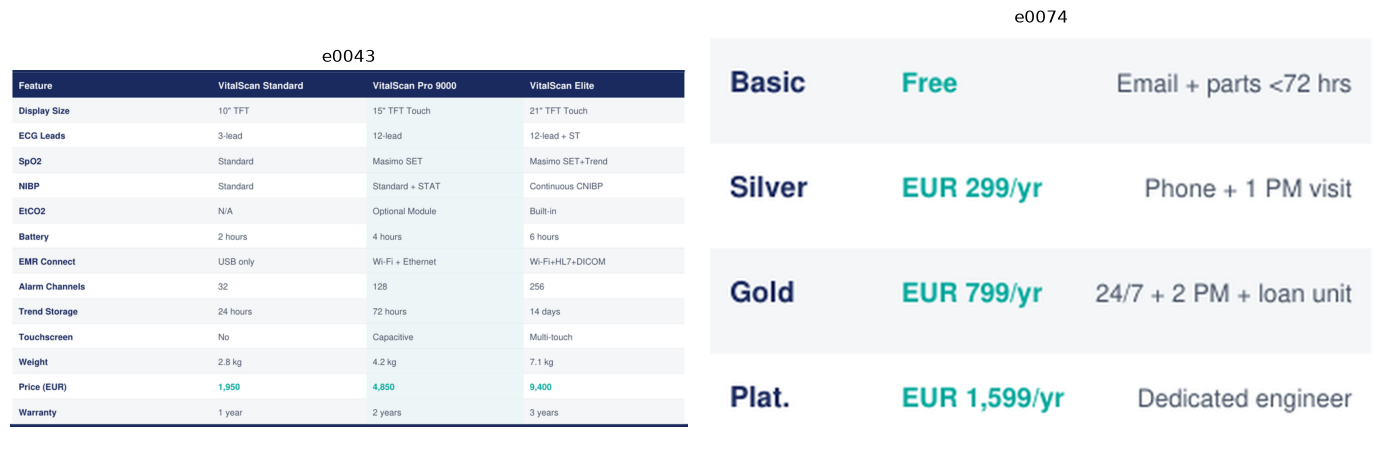

In [6]:
PAD_PX = 4
UPSCALE_FACTOR = 2

def crop_table(page_images, t, pad=PAD_PX, upscale=UPSCALE_FACTOR):
    img = page_images[t["page"]]
    W, H = img.size
    bn = t["bbox_norm"]
    x0 = max(0, bn["x"] * W - pad); y0 = max(0, bn["y"] * H - pad)
    x1 = min(W, (bn["x"] + bn["w"]) * W + pad); y1 = min(H, (bn["y"] + bn["h"]) * H + pad)
    crop = img.crop((x0, y0, x1, y1))
    if upscale != 1:
        crop = crop.resize((crop.width * upscale, crop.height * upscale), Image.LANCZOS)
    return crop

table_crops = {tid: crop_table(page_images, t) for tid, t in table_gt.items() if t["page"] is not None}

fig, axes = plt.subplots(1, len(table_crops), figsize=(7 * len(table_crops), 5))
if len(table_crops) == 1:
    axes = [axes]
for ax, (tid, crop) in zip(axes, table_crops.items()):
    ax.imshow(crop)
    ax.set_title(tid)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Grid Reconstruction Baseline (shared logic)

Both OCR engines return only word-level boxes, no table structure. This shared
function clusters word boxes into rows (gap-based clustering on y-center) and
columns (largest-gap heuristic on x-center, given a target column count from
the GT — a real-world pipeline wouldn't know the column count in advance, but
since the goal here is to isolate *content* extraction quality rather than
*column-count detection*, we fix `n_cols` from GT and let the metric capture
row/cell-level errors instead). This is a deliberately simple baseline — swap
in Table-Transformer/Docling here for a stronger comparison point later.

In [7]:
def cluster_1d_by_gap(values, gap_ratio, typical_size):
    idx_sorted = sorted(range(len(values)), key=lambda i: values[i])
    clusters, current = [], [idx_sorted[0]]
    for i in idx_sorted[1:]:
        if values[i] - values[current[-1]] > gap_ratio * typical_size:
            clusters.append(current); current = [i]
        else:
            current.append(i)
    clusters.append(current)
    return clusters

def words_to_grid_html(words, n_cols, has_header_row, has_header_col):
    """words: list of dicts with text/cx/cy/h/w (pixel coords). Returns
    (html_str, grid_rows_as_list_of_lists)."""
    if not words:
        return "<table><tbody><tr><td></td></tr></tbody></table>", [[]]

    avg_h = float(np.mean([w["h"] for w in words]))
    row_groups = cluster_1d_by_gap([w["cy"] for w in words], 0.8, avg_h)
    rows = [sorted([words[i] for i in g], key=lambda w: w["cx"]) for g in row_groups]
    rows.sort(key=lambda r: np.mean([w["cy"] for w in r]))

    all_cx = sorted(w["cx"] for r in rows for w in r)
    if n_cols > 1 and len(all_cx) >= n_cols:
        gaps = np.diff(all_cx)
        top_gap_idx = np.argsort(gaps)[::-1][: n_cols - 1]
        boundaries = sorted(all_cx[i] + gaps[i] / 2 for i in top_gap_idx)
    else:
        boundaries = []

    def col_index(cx):
        for i, b in enumerate(boundaries):
            if cx < b:
                return i
        return len(boundaries)

    grid = []
    for row in rows:
        cell_words = {}
        for w in row:
            ci = col_index(w["cx"])
            cell_words.setdefault(ci, []).append(w["text"])
        grid.append([" ".join(cell_words.get(c, [])) for c in range(n_cols)])

    from html import escape
    lines = ["<table>"]
    body_rows = grid
    if has_header_row and grid:
        lines.append("  <thead>")
        lines.append("    <tr>" + "".join(f"<th>{escape(v)}</th>" for v in grid[0]) + "</tr>")
        lines.append("  </thead>")
        body_rows = grid[1:]
    lines.append("  <tbody>")
    for row in body_rows:
        cells_html = []
        for j, v in enumerate(row):
            tag = "th" if (j == 0 and has_header_col) else "td"
            cells_html.append(f"<{tag}>{escape(v)}</{tag}>")
        lines.append("    <tr>" + "".join(cells_html) + "</tr>")
    lines.append("  </tbody>")
    lines.append("</table>")
    return "\n".join(lines), grid


## 6. Baseline Model 1 — Tesseract

In [8]:
import pytesseract
import os
if os.name == 'nt':
    tess_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
    if os.path.exists(tess_path):
        pytesseract.pytesseract.tesseract_cmd = tess_path

from pytesseract import Output

try:
    print("Tesseract version:", pytesseract.get_tesseract_version())
except Exception as e:
    raise RuntimeError("Tesseract binary not found — check Internet is ON and apt-get succeeded.") from e

def tesseract_words(crop_img):
    data = pytesseract.image_to_data(crop_img, output_type=Output.DICT, config="--psm 6")
    words = []
    for i in range(len(data["text"])):
        txt = data["text"][i].strip()
        if not txt:
            continue
        words.append({
            "text": txt, "left": data["left"][i], "top": data["top"][i],
            "width": data["width"][i], "height": data["height"][i],
            "cx": data["left"][i] + data["width"][i] / 2,
            "cy": data["top"][i] + data["height"][i] / 2,
            "h": data["height"][i],
        })
    return words

tesseract_table_preds = {}
for tid, crop in tqdm(table_crops.items(), desc="Tesseract"):
    meta = table_gt[tid]["meta"]
    words = tesseract_words(crop)
    html, grid = words_to_grid_html(words, meta["n_cols"], meta["has_header_row"], meta["has_header_col"])
    tesseract_table_preds[tid] = {"html": html, "grid": grid, "n_words": len(words)}
    print(f"{tid}: {len(words)} words -> {len(grid)} reconstructed rows (GT has {meta['n_rows']})")


Tesseract version: 5.4.0.20240606


Tesseract:   0%|          | 0/2 [00:00<?, ?it/s]

Tesseract:  50%|█████     | 1/2 [00:00<00:00,  1.49it/s]

e0043: 85 words -> 13 reconstructed rows (GT has 14)


Tesseract: 100%|██████████| 2/2 [00:00<00:00,  2.25it/s]

Tesseract: 100%|██████████| 2/2 [00:00<00:00,  2.08it/s]

e0074: 31 words -> 4 reconstructed rows (GT has 4)


## 7. Baseline Model 2 — EasyOCR

In [9]:
import torch
import easyocr

USE_GPU = torch.cuda.is_available()
print("EasyOCR GPU:", USE_GPU)
reader = easyocr.Reader(["en"], gpu=USE_GPU, verbose=False)

def easyocr_words(crop_img):
    detections = reader.readtext(np.array(crop_img))
    words = []
    for box, text, conf in detections:
        xs = [p[0] for p in box]; ys = [p[1] for p in box]
        words.append({
            "text": text, "cx": (min(xs) + max(xs)) / 2, "cy": (min(ys) + max(ys)) / 2,
            "h": max(ys) - min(ys), "w": max(xs) - min(xs),
        })
    return words

easyocr_table_preds = {}
for tid, crop in tqdm(table_crops.items(), desc="EasyOCR"):
    meta = table_gt[tid]["meta"]
    words = easyocr_words(crop)
    html, grid = words_to_grid_html(words, meta["n_cols"], meta["has_header_row"], meta["has_header_col"])
    easyocr_table_preds[tid] = {"html": html, "grid": grid, "n_words": len(words)}
    print(f"{tid}: {len(words)} words -> {len(grid)} reconstructed rows (GT has {meta['n_rows']})")


EasyOCR GPU: False


EasyOCR:   0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


EasyOCR:  50%|█████     | 1/2 [00:14<00:14, 14.20s/it]

e0043: 56 words -> 14 reconstructed rows (GT has 14)


EasyOCR: 100%|██████████| 2/2 [00:16<00:00,  6.93s/it]

EasyOCR: 100%|██████████| 2/2 [00:16<00:00,  8.02s/it]

e0074: 13 words -> 4 reconstructed rows (GT has 4)


## 8. TEDS Metric

Implements TEDS (Tree-Edit-Distance-based Similarity, Zhong et al. / PubTabNet)
using the `apted` library: convert each HTML table into a tree of structural
nodes (`table`/`thead`/`tbody`/`tr`/`td`/`th`), where leaf `td`/`th` nodes carry
cell text, then compute a normalized tree-edit-distance similarity. `TEDS-Struct`
strips cell text before comparison, isolating pure structural accuracy.

This implementation is validated below against known-answer cases (identical
tables → 1.0; a single wrong cell → high but <1.0 TEDS, with TEDS-Struct
unaffected; a missing row → both TEDS and TEDS-Struct drop).

In [10]:
from lxml import etree
from apted import APTED, Config
import jiwer as _jiwer

class _TableTree:
    def __init__(self, tag, text=None, children=None):
        self.tag = tag
        self.text = text
        self.children = children or []

def _html_to_tree(html_str):
    root_el = etree.fromstring(f"<root>{html_str}</root>", parser=etree.HTMLParser())
    table_el = root_el.find(".//table")

    def build(el):
        tag = el.tag
        if tag in ("td", "th"):
            text = "".join(el.itertext()).strip()
            return _TableTree(tag, text=text, children=[])
        children = [build(c) for c in el if c.tag in ("thead", "tbody", "tr", "td", "th")]
        return _TableTree(tag, text=None, children=children)

    return build(table_el)

def _strip_content(t):
    if t.tag in ("td", "th"):
        t.text = None
    for c in t.children:
        _strip_content(c)
    return t

def _count_nodes(t):
    return 1 + sum(_count_nodes(c) for c in t.children)

class _TEDSConfig(Config):
    def rename(self, n1, n2):
        if n1.tag != n2.tag:
            return 1.0
        if n1.tag in ("td", "th"):
            t1, t2 = n1.text or "", n2.text or ""
            if t1 == t2:
                return 0.0
            try:
                return min(1.0, _jiwer.cer(t1, t2)) if t1 else 1.0
            except Exception:
                return 1.0
        return 0.0

    def children(self, node):
        return node.children

    def get_label(self, node):
        return node.tag

def teds_score(html_gt, html_pred, structure_only=False):
    t1, t2 = _html_to_tree(html_gt), _html_to_tree(html_pred)
    if structure_only:
        t1, t2 = _strip_content(t1), _strip_content(t2)
    ed = APTED(t1, t2, _TEDSConfig()).compute_edit_distance()
    n = max(_count_nodes(t1), _count_nodes(t2))
    return 1.0 - (ed / n if n else 0.0)

# --- sanity checks (known-answer tests) ---
_gt = "<table><thead><tr><th>A</th><th>B</th></tr></thead><tbody><tr><td>1</td><td>2</td></tr></tbody></table>"
_identical = _gt
_one_wrong = _gt.replace(">2<", ">9<")
assert abs(teds_score(_gt, _identical) - 1.0) < 1e-9, "identical tables must score 1.0"
assert teds_score(_gt, _one_wrong) < 1.0, "a wrong cell must reduce TEDS"
assert abs(teds_score(_gt, _one_wrong, structure_only=True) - 1.0) < 1e-9, \
    "content-only error must not affect TEDS-Struct"
print("TEDS sanity checks passed.")


TEDS sanity checks passed.


## 9. Evaluation — TEDS / TEDS-Struct / Grid Exact-Match

In [11]:
def grid_exact_match_rate(gt_cells, pred_grid, has_header_row):
    """Cheap diagnostic: fraction of GT cells whose text exactly matches the
    predicted grid cell at the same (row, col), after whitespace/case
    normalization. Predicted grid includes the header row as grid[0] if the
    baseline emitted one — align indices accordingly."""
    def norm(s):
        return re.sub(r"\s+", " ", (s or "").strip().lower())

    pred_lookup = {}
    offset = 1 if has_header_row else 0
    for r, row in enumerate(pred_grid):
        for c, val in enumerate(row):
            pred_lookup[(r, c)] = val
    matches, total = 0, 0
    for cell in gt_cells:
        total += 1
        pred_val = pred_lookup.get((cell["row"], cell["col"]), "")
        if norm(pred_val) == norm(cell["text"]):
            matches += 1
    return matches / total if total else float("nan")

records = []
for tid, t in table_gt.items():
    if tid not in table_crops:
        continue
    gt_html = t["html"]
    for model_name, preds in [("tesseract", tesseract_table_preds), ("easyocr", easyocr_table_preds)]:
        pred = preds[tid]
        teds = teds_score(gt_html, pred["html"])
        teds_struct = teds_score(gt_html, pred["html"], structure_only=True)
        grid_acc = grid_exact_match_rate(t["cells"], pred["grid"], t["meta"]["has_header_row"])
        records.append({
            "table_id": tid, "model": model_name,
            "TEDS": teds, "TEDS_Struct": teds_struct, "Grid_Exact_Match": grid_acc,
            "n_words_detected": pred["n_words"],
            "gt_n_rows": t["meta"]["n_rows"], "pred_n_rows": len(pred["grid"]),
        })

results_df = pd.DataFrame(records)
results_df


,table_id,model,TEDS,TEDS_Struct,Grid_Exact_Match,n_words_detected,gt_n_rows,pred_n_rows
0,e0043,tesseract,0.865297,0.931507,0.017857,85,14,13
1,e0043,easyocr,0.979876,1.000000,0.910714,56,14,14
2,e0074,tesseract,0.807018,1.000000,0.500000,31,4,4
3,e0074,easyocr,0.983333,1.000000,0.833333,13,4,4


## 10. Leaderboard

In [12]:
leaderboard = (results_df.groupby("model")[["TEDS", "TEDS_Struct", "Grid_Exact_Match"]]
               .mean()
               .sort_values("TEDS", ascending=False))
print("=== Overall Leaderboard (higher TEDS/TEDS-Struct/Grid-Match is better) ===")
leaderboard


=== Overall Leaderboard (higher TEDS/TEDS-Struct/Grid-Match is better) ===


,TEDS,TEDS_Struct,Grid_Exact_Match
model,,,
easyocr,0.981605,1.000000,0.872024
tesseract,0.836158,0.965753,0.258929


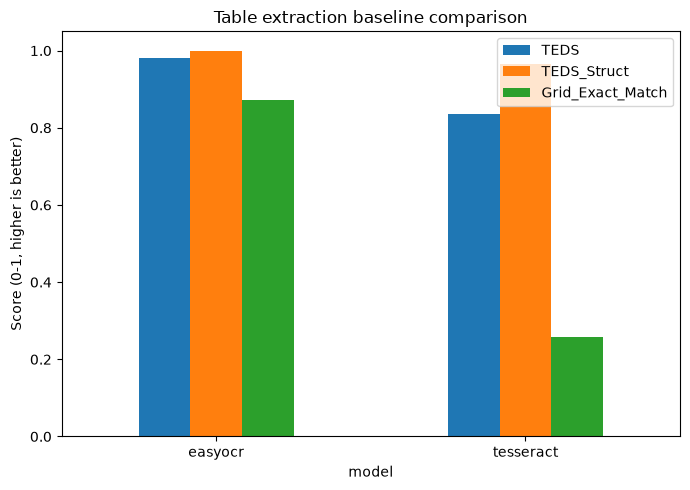

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
leaderboard.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Table extraction baseline comparison")
ax.set_ylabel("Score (0-1, higher is better)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 11. Qualitative Inspection — Predicted vs GT HTML

In [14]:
for tid in table_gt:
    if tid not in table_crops:
        continue
    print(f"\n{'='*70}\n{tid} -- GT Markdown\n{'='*70}")
    print(table_gt[tid]["markdown"])
    for model_name, preds in [("tesseract", tesseract_table_preds), ("easyocr", easyocr_table_preds)]:
        print(f"\n--- {model_name} reconstructed grid ---")
        for row in preds[tid]["grid"]:
            print(row)



e0043 -- GT Markdown
| Feature | VitalScan Standard | VitalScan Pro 9000 | VitalScan Elite |
|---|---|---|---|
| Display Size | 10" TFT | 15" TFT Touch | 21" TFT Touch |
| ECG Leads | 3-lead | 12-lead | 12-lead + ST |
| SpO2 | Standard | Masimo SET | Masimo SET+Trend |
| NIBP | Standard | Standard + STAT | Continuous CNIBP |
| EtCO2 | N/A | Optional Module | Built-in |
| Battery | 2 hours | 4 hours | 6 hours |
| EMR Connect | USB only | Wi-Fi + Ethernet | Wi-Fi+HL7+DICOM |
| Alarm Channels | 32 | 128 | 256 |
| Trend Storage | 24 hours | 72 hours | 14 days |
| Touchscreen | No | Capacitive | Multi-touch |
| Weight | 2.8 kg | 4.2 kg | 7.1 kg |
| Price (EUR) | 1,950 | 4,850 | 9,400 |
| Warranty | 1 year | 2 years | 3 years |

--- tesseract reconstructed grid ---
['Display Size', '10" TFT', '15" TFT Touch', '21" TFT Touch']
['ECG Leads', '3-lead', '12-lead', '12-lead + ST']
['Spo02', 'Standard', 'Masimo SET', 'Masimo SET+Trend']
['NIBP', 'Standard', 'Standard + STAT', 'Continuous CNIBP']


## 12. Save Outputs

In [15]:
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_path = os.path.join(OUTPUT_DIR, "table_extraction_benchmark_results.csv")
leaderboard_path = os.path.join(OUTPUT_DIR, "table_extraction_benchmark_leaderboard.csv")

results_df.to_csv(results_path, index=False)
leaderboard.to_csv(leaderboard_path)

print("Saved:")
for p in [results_path, leaderboard_path]:
    print(" -", p)


Saved:
 - /kaggle/working\table_extraction_benchmark_results.csv
 - /kaggle/working\table_extraction_benchmark_leaderboard.csv


## Summary

This notebook benchmarks simple **grid-reconstruction baselines built on Tesseract and EasyOCR**
against the 2 verified tables in the MedCore catalogue, using **TEDS** and **TEDS-Struct**
(implemented with `apted`, validated against known-answer test cases) plus a cell-level
exact-match rate.

Both baselines lack any real table-structure understanding (no rowspan/colspan detection,
header-row detection is GT-assisted here rather than inferred), so expect meaningfully
lower scores than a purpose-built table model would achieve — that gap **is the finding**.

**Next steps:**
- Add a real table-structure baseline (Table-Transformer / Docling TableFormer / MinerU) to this
  same harness for a much stronger comparison point.
- Add the Tier-2 Claude-as-judge rubric scorer from the benchmarking research report, which
  correlates better with human judgment than TEDS/GriTS alone.
- Move to Track C (Image) once Table is finalized.
